In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

# Give colab access to google drive

In [ ]:
# give colab access to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Baboon image

Pixel max and min:
230 0
Number of unique pixel intensities in image:  226


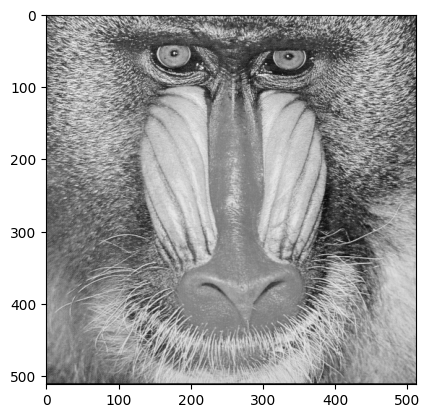

In [ ]:
# load image
import numpy as np
import scipy.io as sio

# image path
work_path = '/content/drive/MyDrive/DigitalImageProcessing/'

# load image
img = sio.loadmat(work_path + 'Data/baboon.mat')['baboon']

# plot image
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(img, cmap='gray')

print('Pixel max and min:')
print(img.max(), img.min())

uni = np.unique(img)
print('Number of unique pixel intensities in image: ',len(uni))


# Lloyd-Max Quantizer

Flatten the peper image into a long vector

In [ ]:
import numpy as np
x = img.flatten()/255

Lloyd-Max Quantizer



In [ ]:
import scipy.integrate as integrate
from scipy.stats import norm


def normal_dist(x, mean=1.0, vari=1.0):
    """A normal distribution function created to use with scipy.integral.quad
    """
    return (1.0/(np.sqrt(2.0*np.pi*vari)))*np.exp((-np.power((x-mean),2.0))/(2.0*vari))


def expected_normal_dist(x, mean=1.0, vari=1.0):
    """A expected value of normal distribution function which created to use with scipy.integral.quad
    """
    return (x/(np.sqrt(2.0*np.pi*vari)))*np.exp((-np.power((x-mean),2.0))/(2.0*vari))


def start_repre(x, bit):
        """
          A "random guess"
        """
        assert isinstance(bit, int)
        x = np.array(x)
        num_repre  = np.power(2,bit)
        step = (np.max(x)-np.min(x))/num_repre

        middle_point = np.mean(x)
        repre = np.array([])
        for i in range(int(num_repre/2)):
             repre = np.append(repre, middle_point+(i+1)*step)
             repre = np.insert(repre, 0, middle_point-(i+1)*step)
        return repre

def threshold(repre):
    """
    """
    t_q = np.zeros(np.size(repre)-1)
    for i in range(len(repre)-1):
        t_q[i] = 0.5*(repre[i]+repre[i+1])
    return t_q

def represent(thre, expected_dist, dist):
    """
    """
    thre = np.array(thre)
    x_hat_q = np.zeros(np.size(thre)+1)
    #prepare for all possible integration range
    thre = np.append(thre, np.inf)
    thre = np.insert(thre, 0, -np.inf)

    for i in range(len(thre)-1):
        # a = (integrate.quad(dist,thre[i],thre[i+1])[0])
        # print(a)
        x_hat_q[i] = integrate.quad(expected_dist, thre[i], thre[i+1])[0]/(integrate.quad(dist,thre[i],thre[i+1])[0])
    return x_hat_q

def quant(x, thre, repre):
    thre = np.append(thre, np.inf)
    thre = np.insert(thre, 0, -np.inf)
    x_hat_q = np.zeros(np.shape(x))
    for i in range(len(thre)-1):
        if i == 0 or i == len(thre)-2:
            x_hat_q = np.where(np.logical_and(x > thre[i], x <= thre[i+1]),
                                np.full(np.size(x_hat_q), repre[i]), x_hat_q)
        else:
            x_hat_q = np.where(np.logical_and(x > thre[i], x < thre[i+1]),
                                np.full(np.size(x_hat_q), repre[i]), x_hat_q)
    return x_hat_q

bit = 6
iteration = 5000
repre = start_repre(x, bit)
for _ in range(iteration):
    thre = threshold(repre)
    repre = represent(thre, expected_normal_dist, normal_dist)
x_hat_q = quant(x, thre, repre)

Plot the quantized image

(262144,)
(512, 512)


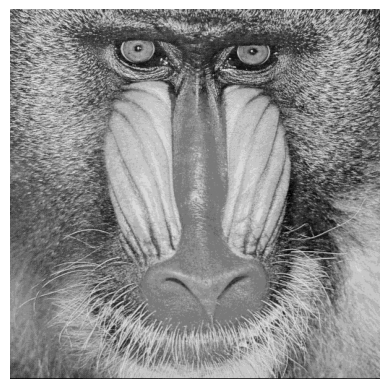

In [ ]:
print(x_hat_q.shape)
print(img.shape)
img_hat = np.reshape(x_hat_q, img.shape)

plt.imshow(img_hat, cmap='gray')
plt.axis('off')

# SNR and MSE Evaluation

In [ ]:
import numpy as np

def snr_dB(actu,pred):
    err = pred.astype(np.float32) - actu.astype(np.float32)
    sigma_n = np.var(err)
    sigma_s = np.var(actu)
    ns = sigma_s/sigma_n
    snr = np.mean(10 * np.log10(ns))
    return snr

def MSE(actu, pred):
     return np.square(actu - pred).mean()

# print SNR and MSE
print('SNR:', np.round(snr_dB(x, x_hat_q),6))
print('MSE:', np.round(MSE(x*255, x_hat_q*255), 6))

SNR: 18.384929
MSE: 25.95238
